In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import cv2

DATASET_PATH = r"C:\Users\HP\Documents\DS605-Fundamentals-of-Machine-Learning\LAB06\448"

print(os.listdir(DATASET_PATH))

print("OpenCV version:", cv2.__version__)

['Cracks', 'NonCracks']
OpenCV version: 5.0.0


In [5]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

crack_path = os.path.join(DATASET_PATH, "cracks")
non_crack_path = os.path.join(DATASET_PATH, "noncracks")

crack_images = [
    f for f in os.listdir(crack_path)
    if f.lower().endswith(image_extensions)
]

non_crack_images = [
    f for f in os.listdir(non_crack_path)
    if f.lower().endswith(image_extensions)
]

print("Crack images:", len(crack_images))
print("Non-crack images:", len(non_crack_images))
print("Total images:", len(crack_images) + len(non_crack_images))

Crack images: 200
Non-crack images: 200
Total images: 400


In [6]:
IMG_SIZE = (128, 128)

def preprocess_image(image_path):
    image = cv2.imread(image_path)
    
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    image = cv2.resize(image, IMG_SIZE)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    return image, gray

In [7]:
sample_path = os.path.join(crack_path, crack_images[0])

color_image, gray_image = preprocess_image(sample_path)

print("Original/loaded image shape:", color_image.shape)
print("Grayscale image shape:", gray_image.shape)
print("Minimum grayscale value:", gray_image.min())
print("Maximum grayscale value:", gray_image.max())

Original/loaded image shape: (128, 128, 3)
Grayscale image shape: (128, 128)
Minimum grayscale value: 27
Maximum grayscale value: 247


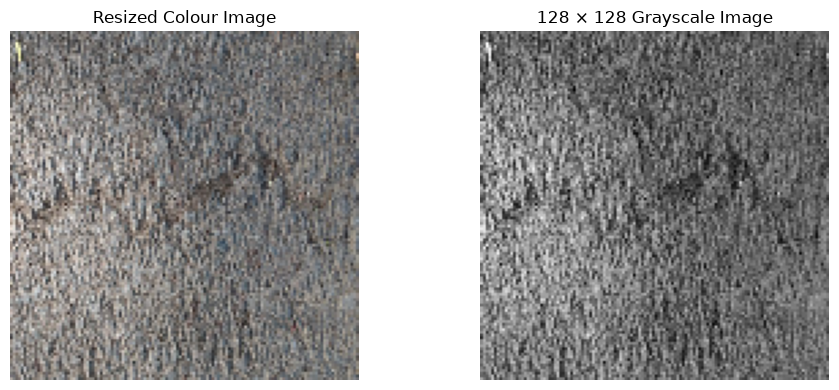

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.title("Resized Colour Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("128 × 128 Grayscale Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
def extract_intensity_features(gray_image):
    mean_intensity = np.mean(gray_image)
    std_intensity = np.std(gray_image)
    min_intensity = np.min(gray_image)
    max_intensity = np.max(gray_image)

    return {
        "mean_intensity": mean_intensity,
        "std_intensity": std_intensity,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity
    }

intensity_features = extract_intensity_features(gray_image)

print(intensity_features)

{'mean_intensity': np.float64(122.26397705078125), 'std_intensity': np.float64(33.070752030262774), 'min_intensity': np.uint8(27), 'max_intensity': np.uint8(247)}


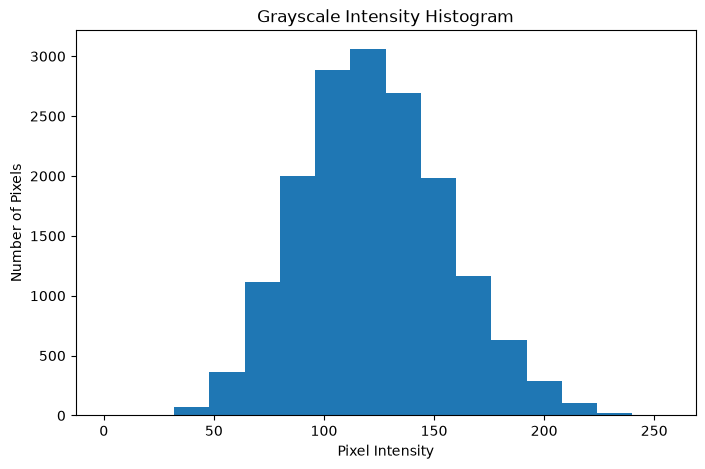

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(
    gray_image.ravel(),
    bins=16,
    range=(0, 256)
)

plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.title("Grayscale Intensity Histogram")
plt.show()

In [12]:
histogram, bin_edges = np.histogram(
    gray_image,
    bins=16,
    range=(0, 256)
)

print("Histogram:", histogram)
print("Number of histogram features:", len(histogram))

Histogram: [   0    3   70  366 1115 1998 2885 3062 2696 1981 1163  629  292  101
   19    4]
Number of histogram features: 16


In [13]:
def extract_intensity_features(gray_image):
    features = {
        "mean_intensity": np.mean(gray_image),
        "std_intensity": np.std(gray_image),
        "min_intensity": np.min(gray_image),
        "max_intensity": np.max(gray_image)
    }

    histogram, _ = np.histogram(
        gray_image,
        bins=16,
        range=(0, 256)
    )

    for i, value in enumerate(histogram):
        features[f"hist_bin_{i+1}"] = value

    return features


intensity_features = extract_intensity_features(gray_image)

print("Number of features:", len(intensity_features))
print(intensity_features)

Number of features: 20
{'mean_intensity': np.float64(122.26397705078125), 'std_intensity': np.float64(33.070752030262774), 'min_intensity': np.uint8(27), 'max_intensity': np.uint8(247), 'hist_bin_1': np.int64(0), 'hist_bin_2': np.int64(3), 'hist_bin_3': np.int64(70), 'hist_bin_4': np.int64(366), 'hist_bin_5': np.int64(1115), 'hist_bin_6': np.int64(1998), 'hist_bin_7': np.int64(2885), 'hist_bin_8': np.int64(3062), 'hist_bin_9': np.int64(2696), 'hist_bin_10': np.int64(1981), 'hist_bin_11': np.int64(1163), 'hist_bin_12': np.int64(629), 'hist_bin_13': np.int64(292), 'hist_bin_14': np.int64(101), 'hist_bin_15': np.int64(19), 'hist_bin_16': np.int64(4)}


In [14]:
edges = cv2.Canny(gray_image, 100, 200)

print("Edge image shape:", edges.shape)
print("Unique values:", np.unique(edges))

Edge image shape: (128, 128)
Unique values: [  0 255]


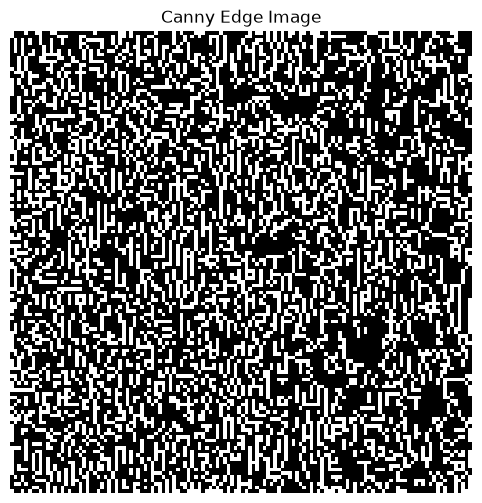

In [15]:
plt.figure(figsize=(6, 6))

plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Image")
plt.axis("off")

plt.show()

In [16]:
edge_pixels = np.sum(edges > 0)
total_pixels = edges.size

edge_density = edge_pixels / total_pixels

print("Edge pixels:", edge_pixels)
print("Total pixels:", total_pixels)
print("Edge density:", edge_density)

Edge pixels: 5580
Total pixels: 16384
Edge density: 0.340576171875


In [17]:
def extract_edge_features(gray_image):
    edges = cv2.Canny(gray_image, 100, 200)

    edge_pixels = np.sum(edges > 0)
    total_pixels = edges.size
    edge_density = edge_pixels / total_pixels

    features = {
        "edge_pixels": edge_pixels,
        "edge_density": edge_density
    }

    return features, edges

edge_features, edges = extract_edge_features(gray_image)

print(edge_features)

{'edge_pixels': np.int64(5580), 'edge_density': np.float64(0.340576171875)}


In [18]:
def extract_all_features(image_path, label):
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.resize(image, IMG_SIZE)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    features = {
        "mean_intensity": np.mean(gray),
        "std_intensity": np.std(gray),
        "min_intensity": np.min(gray),
        "max_intensity": np.max(gray)
    }

    histogram, _ = np.histogram(
        gray,
        bins=16,
        range=(0, 256)
    )

    for i, value in enumerate(histogram):
        features[f"hist_bin_{i+1}"] = value

    edges = cv2.Canny(gray, 100, 200)

    edge_pixels = np.sum(edges > 0)
    edge_density = edge_pixels / edges.size

    features["edge_pixels"] = edge_pixels
    features["edge_density"] = edge_density

    features["label"] = label

    return features


In [19]:
crack_test = extract_all_features(
    os.path.join(crack_path, crack_images[0]),
    1
)

non_crack_test = extract_all_features(
    os.path.join(non_crack_path, non_crack_images[0]),
    0
)

print("Number of features:", len(crack_test))
print(crack_test)

Number of features: 23
{'mean_intensity': np.float64(122.26397705078125), 'std_intensity': np.float64(33.070752030262774), 'min_intensity': np.uint8(27), 'max_intensity': np.uint8(247), 'hist_bin_1': np.int64(0), 'hist_bin_2': np.int64(3), 'hist_bin_3': np.int64(70), 'hist_bin_4': np.int64(366), 'hist_bin_5': np.int64(1115), 'hist_bin_6': np.int64(1998), 'hist_bin_7': np.int64(2885), 'hist_bin_8': np.int64(3062), 'hist_bin_9': np.int64(2696), 'hist_bin_10': np.int64(1981), 'hist_bin_11': np.int64(1163), 'hist_bin_12': np.int64(629), 'hist_bin_13': np.int64(292), 'hist_bin_14': np.int64(101), 'hist_bin_15': np.int64(19), 'hist_bin_16': np.int64(4), 'edge_pixels': np.int64(5580), 'edge_density': np.float64(0.340576171875), 'label': 1}


In [20]:
all_features = []

# Crack images → label 1
for filename in crack_images:
    image_path = os.path.join(crack_path, filename)
    features = extract_all_features(image_path, 1)
    all_features.append(features)

# Non-crack images → label 0
for filename in non_crack_images:
    image_path = os.path.join(non_crack_path, filename)
    features = extract_all_features(image_path, 0)
    all_features.append(features)

print("Total images processed:", len(all_features))

Total images processed: 400


In [23]:
features_df = pd.DataFrame(all_features)

print("Feature table shape:", features_df.shape)
print("\nColumns:")
print(features_df.columns.tolist())

Feature table shape: (400, 23)

Columns:
['mean_intensity', 'std_intensity', 'min_intensity', 'max_intensity', 'hist_bin_1', 'hist_bin_2', 'hist_bin_3', 'hist_bin_4', 'hist_bin_5', 'hist_bin_6', 'hist_bin_7', 'hist_bin_8', 'hist_bin_9', 'hist_bin_10', 'hist_bin_11', 'hist_bin_12', 'hist_bin_13', 'hist_bin_14', 'hist_bin_15', 'hist_bin_16', 'edge_pixels', 'edge_density', 'label']


In [24]:
features_df.head()
print(features_df["label"].value_counts())

label
1    200
0    200
Name: count, dtype: int64


In [25]:
X = features_df.drop(columns=["label"])
y = features_df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 22)
y shape: (400,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTest labels:")
print(y_test.value_counts())

Training features: (320, 22)
Test features: (80, 22)

Training labels:
label
1    160
0    160
Name: count, dtype: int64

Test labels:
label
0    40
1    40
Name: count, dtype: int64


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

start_train = time.time()
tree_model.fit(X_train, y_train)
tree_train_time = time.time() - start_train

start_predict = time.time()
y_pred_tree = tree_model.predict(X_test)
tree_predict_time = time.time() - start_predict

print("Decision Tree trained successfully.")
print("Training time:", round(tree_train_time, 5), "seconds")
print("Prediction time:", round(tree_predict_time, 5), "seconds")

Decision Tree trained successfully.
Training time: 0.00572 seconds
Prediction time: 0.00184 seconds


In [33]:
print("Accuracy:", round(accuracy_score(y_test, y_pred_tree), 4))
print("Precision:", round(precision_score(y_test, y_pred_tree, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_pred_tree, zero_division=0), 4))
print("F1-score:", round(f1_score(y_test, y_pred_tree, zero_division=0), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Accuracy: 0.95
Precision: 0.9286
Recall: 0.975
F1-score: 0.9512

Confusion Matrix:
[[37  3]
 [ 1 39]]


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_tree, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_tree, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_tree, zero_division=0)
    ],
    "Training time (s)": [
        logistic_train_time if "logistic_train_time" in globals() else None,
        tree_train_time
    ],
    "Prediction time (s)": [
        logistic_predict_time if "logistic_predict_time" in globals() else None,
        tree_predict_time
    ]
})

print(comparison_df.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-score  Training time (s)  Prediction time (s)
Logistic Regression      0.95     0.9500   0.950    0.9500                NaN                  NaN
      Decision Tree      0.95     0.9286   0.975    0.9512             0.0057               0.0018


In [35]:
import time

start_train = time.time()
logistic_model.fit(X_train, y_train)
logistic_train_time = time.time() - start_train

start_predict = time.time()
y_pred_lr = logistic_model.predict(X_test)
logistic_predict_time = time.time() - start_predict

print("Logistic Regression training time:", round(logistic_train_time, 6), "seconds")
print("Logistic Regression prediction time:", round(logistic_predict_time, 6), "seconds")

Logistic Regression training time: 0.018242 seconds
Logistic Regression prediction time: 0.001537 seconds


In [36]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_tree, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_tree, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_tree, zero_division=0)
    ],
    "Training time (s)": [logistic_train_time, tree_train_time],
    "Prediction time (s)": [logistic_predict_time, tree_predict_time]
})

print(comparison_df.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-score  Training time (s)  Prediction time (s)
Logistic Regression      0.95     0.9500   0.950    0.9500             0.0182               0.0015
      Decision Tree      0.95     0.9286   0.975    0.9512             0.0057               0.0018


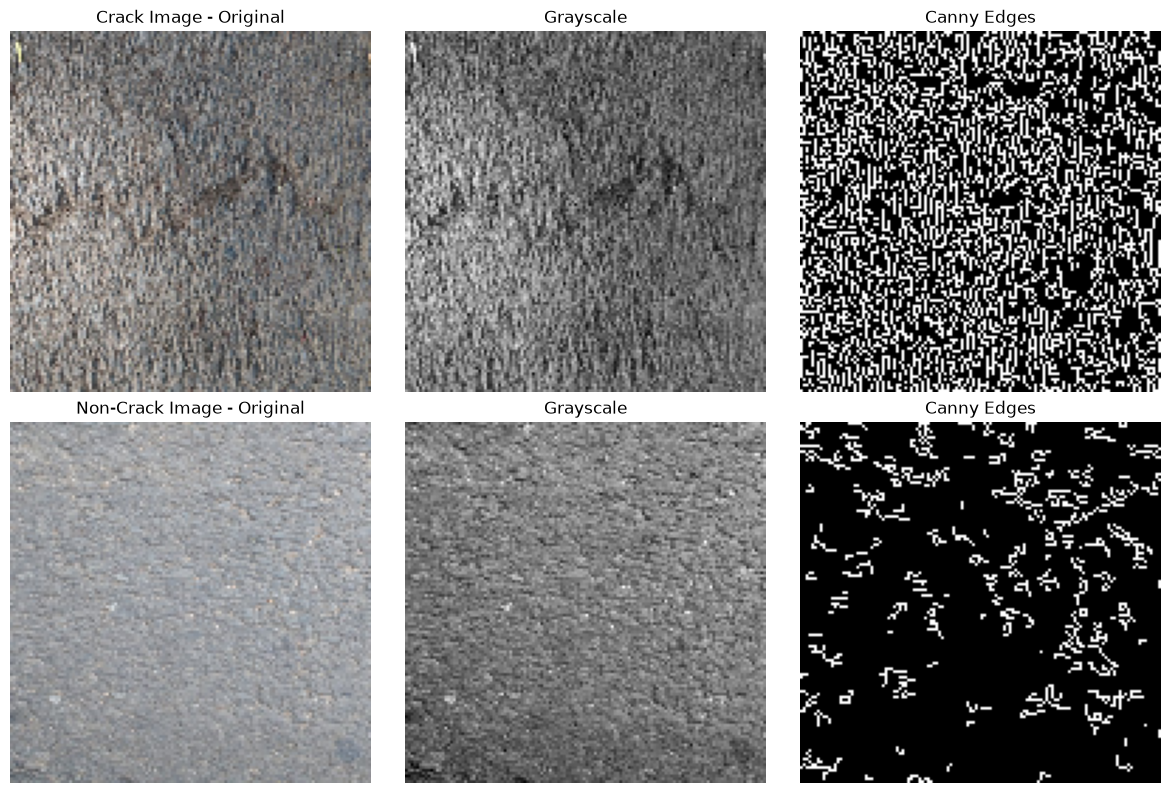

In [37]:
import os
import cv2
import matplotlib.pyplot as plt

sample_crack = os.path.join(crack_path, crack_images[0])
sample_noncrack = os.path.join(non_crack_path, non_crack_images[0])

samples = [
    ("Crack Image", sample_crack),
    ("Non-Crack Image", sample_noncrack)
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row, (label, image_path) in enumerate(samples):
    image = cv2.imread(image_path)
    image = cv2.resize(image, IMG_SIZE)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    axes[row, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"{label} - Original")

    axes[row, 1].imshow(gray, cmap="gray")
    axes[row, 1].set_title("Grayscale")

    axes[row, 2].imshow(edges, cmap="gray")
    axes[row, 2].set_title("Canny Edges")

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [41]:
import os
import cv2
import numpy as np
import pandas as pd

base_path = r"C:\Users\HP\Documents\DS605-Fundamentals-of-Machine-Learning\LAB06\448"
crack_path = os.path.join(base_path, "cracks")
non_crack_path = os.path.join(base_path, "noncracks")
IMG_SIZE = (128, 128)

def extract_all_features(image_path, label):
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.resize(image, IMG_SIZE)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    features = {
        "mean_intensity": np.mean(gray),
        "std_intensity": np.std(gray),
        "min_intensity": np.min(gray),
        "max_intensity": np.max(gray),
        "dark_pixel_ratio": np.mean(gray < 50),
        "bright_pixel_ratio": np.mean(gray > 200)
    }

    hist = cv2.calcHist([gray], [0], None, [16], [0, 256]).flatten()

    for i, value in enumerate(hist):
        features[f"hist_{i}"] = value

    edges = cv2.Canny(gray, 100, 200)
    features["edge_pixel_count"] = np.sum(edges > 0)
    features["edge_density"] = np.mean(edges > 0)
    features["label"] = label

    return features

all_features = []

for filename in os.listdir(crack_path):
    filepath = os.path.join(crack_path, filename)
    if os.path.isfile(filepath):
        all_features.append(extract_all_features(filepath, 1))

for filename in os.listdir(non_crack_path):
    filepath = os.path.join(non_crack_path, filename)
    if os.path.isfile(filepath):
        all_features.append(extract_all_features(filepath, 0))

features_df = pd.DataFrame(all_features)

print("Feature table shape:", features_df.shape)
print("\nClass distribution:")
print(features_df["label"].value_counts())
print("\nNew features:")
print(features_df[["dark_pixel_ratio", "bright_pixel_ratio"]].head())

Feature table shape: (400, 25)

Class distribution:
label
1    200
0    200
Name: count, dtype: int64

New features:
   dark_pixel_ratio  bright_pixel_ratio
0          0.005859            0.014465
1          0.003418            0.004456
2          0.014221            0.010498
3          0.002197            0.006592
4          0.003357            0.007751


In [42]:
from sklearn.model_selection import train_test_split

X = features_df.drop(columns=["label"])
y = features_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training features: (320, 24)
Testing features: (80, 24)

Training class distribution:
label
1    160
0    160
Name: count, dtype: int64

Testing class distribution:
label
0    40
1    40
Name: count, dtype: int64


In [43]:
import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

start = time.time()
logistic_model.fit(X_train, y_train)
logistic_train_time = time.time() - start

start = time.time()
y_pred_lr = logistic_model.predict(X_test)
logistic_predict_time = time.time() - start

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

start = time.time()
tree_model.fit(X_train, y_train)
tree_train_time = time.time() - start

start = time.time()
y_pred_tree = tree_model.predict(X_test)
tree_predict_time = time.time() - start

print("Both classifiers retrained successfully.")
print("Logistic Regression training time:", round(logistic_train_time, 6), "seconds")
print("Logistic Regression prediction time:", round(logistic_predict_time, 6), "seconds")
print("Decision Tree training time:", round(tree_train_time, 6), "seconds")
print("Decision Tree prediction time:", round(tree_predict_time, 6), "seconds")

Both classifiers retrained successfully.
Logistic Regression training time: 0.013573 seconds
Logistic Regression prediction time: 0.001589 seconds
Decision Tree training time: 0.003241 seconds
Decision Tree prediction time: 0.001046 seconds


In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import pandas as pd

results = []

for model_name, predictions in [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree", y_pred_tree)
]:
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-score": f1_score(y_test, predictions, zero_division=0)
    })

comparison_df = pd.DataFrame(results)

print("FINAL MODEL COMPARISON")
print(comparison_df.round(4).to_string(index=False))

print("\nLOGISTIC REGRESSION CONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred_lr))

print("\nDECISION TREE CONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred_tree))

FINAL MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1-score
Logistic Regression    0.9500      0.950   0.950    0.9500
      Decision Tree    0.9375      0.907   0.975    0.9398

LOGISTIC REGRESSION CONFUSION MATRIX
[[38  2]
 [ 2 38]]

DECISION TREE CONFUSION MATRIX
[[36  4]
 [ 1 39]]


In [45]:
import os
import pandas as pd

base_path = r"C:\Users\HP\Documents\DS605-Fundamentals-of-Machine-Learning\LAB06\448"
output_path = os.path.join(base_path, "outputs")
os.makedirs(output_path, exist_ok=True)

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_tree, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_tree, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_tree, zero_division=0)
    ],
    "Training time (s)": [logistic_train_time, tree_train_time],
    "Prediction time (s)": [logistic_predict_time, tree_predict_time]
})

features_df.to_csv(
    os.path.join(output_path, "asphalt_image_features.csv"),
    index=False
)

comparison_df.to_csv(
    os.path.join(output_path, "model_comparison.csv"),
    index=False
)

print("Feature table saved:", os.path.exists(
    os.path.join(output_path, "asphalt_image_features.csv")
))
print("Comparison table saved:", os.path.exists(
    os.path.join(output_path, "model_comparison.csv")
))
print("\n", comparison_df.round(4).to_string(index=False))

Feature table saved: True
Comparison table saved: True

               Model  Accuracy  Precision  Recall  F1-score  Training time (s)  Prediction time (s)
Logistic Regression    0.9500      0.950   0.950    0.9500             0.0136               0.0016
      Decision Tree    0.9375      0.907   0.975    0.9398             0.0032               0.0010


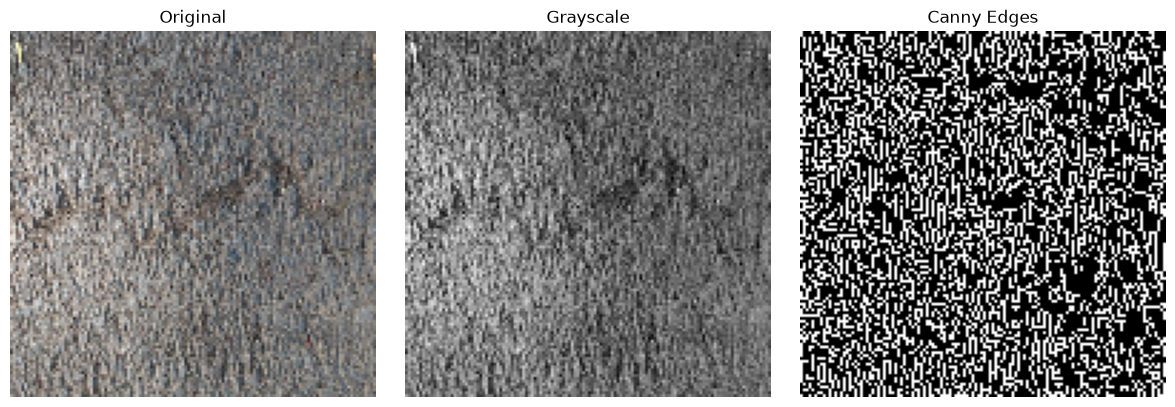

Saved: C:\Users\HP\Documents\DS605-Fundamentals-of-Machine-Learning\LAB06\448\outputs\crack_visualization.png


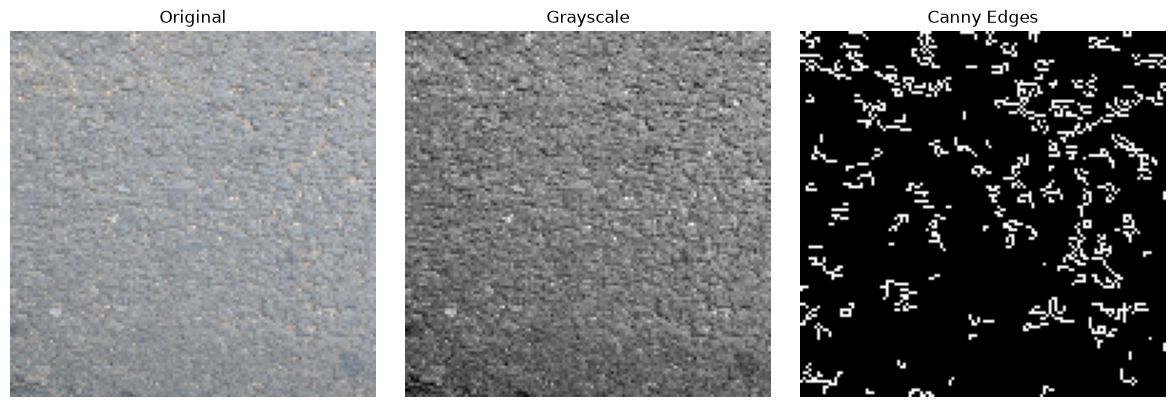

Saved: C:\Users\HP\Documents\DS605-Fundamentals-of-Machine-Learning\LAB06\448\outputs\noncrack_visualization.png


In [46]:
import os
import cv2
import matplotlib.pyplot as plt

base_path = r"C:\Users\HP\Documents\DS605-Fundamentals-of-Machine-Learning\LAB06\448"
output_path = os.path.join(base_path, "outputs")
os.makedirs(output_path, exist_ok=True)

samples = [
    ("crack", os.path.join(crack_path, crack_images[0])),
    ("noncrack", os.path.join(non_crack_path, non_crack_images[0]))
]

for label, image_path in samples:
    image = cv2.imread(image_path)
    image = cv2.resize(image, IMG_SIZE)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")

    axes[1].imshow(gray, cmap="gray")
    axes[1].set_title("Grayscale")

    axes[2].imshow(edges, cmap="gray")
    axes[2].set_title("Canny Edges")

    for ax in axes:
        ax.axis("off")

    fig.tight_layout()
    save_path = os.path.join(output_path, f"{label}_visualization.png")
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Saved:", save_path)

## Part B

In [47]:
import pandas as pd
import os

file_path = r"C:\Users\HP\Documents\DS605-Fundamentals-of-Machine-Learning\LAB06\emails.csv"

print("File exists:", os.path.exists(file_path))

emails_df = pd.read_csv(file_path)

print("Dataset shape:", emails_df.shape)
print("\nColumn names:")
print(emails_df.columns.tolist())

print("\nFirst 5 rows:")
display(emails_df.head())

print("\nDataset information:")
emails_df.info()

print("\nMissing values:")
print(emails_df.isnull().sum())

File exists: True
Dataset shape: (5172, 3002)

Column names:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'ch

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), str(1)
memory usage: 118.5 MB

Missing values:
Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64


In [48]:
print("Dataset shape:", emails_df.shape)

print("\nColumn names and data types:")
print(emails_df.dtypes)

print("\nSample values from each column:")
for column in emails_df.columns:
    print(f"\n--- {column} ---")
    print(emails_df[column].head(3).to_list())

print("\nUnique-value counts for columns with few distinct values:")
for column in emails_df.columns:
    if emails_df[column].nunique(dropna=True) <= 20:
        print(f"\n{column}:")
        print(emails_df[column].value_counts(dropna=False).head(20))

Dataset shape: (5172, 3002)

Column names and data types:
Email No.       str
the           int64
to            int64
ect           int64
and           int64
              ...  
military      int64
allowing      int64
ff            int64
dry           int64
Prediction    int64
Length: 3002, dtype: object

Sample values from each column:

--- Email No. ---
['Email 1', 'Email 2', 'Email 3']

--- the ---
[0, 8, 0]

--- to ---
[0, 13, 0]

--- ect ---
[1, 24, 1]

--- and ---
[0, 6, 0]

--- for ---
[0, 6, 0]

--- of ---
[0, 2, 0]

--- a ---
[2, 102, 8]

--- you ---
[0, 1, 0]

--- hou ---
[0, 27, 0]

--- in ---
[0, 18, 4]

--- on ---
[0, 21, 2]

--- is ---
[1, 13, 0]

--- this ---
[0, 0, 0]

--- enron ---
[0, 1, 0]

--- i ---
[2, 61, 8]

--- be ---
[0, 4, 0]

--- that ---
[0, 2, 0]

--- will ---
[0, 0, 0]

--- have ---
[0, 0, 0]

--- with ---
[0, 2, 0]

--- your ---
[0, 0, 0]

--- at ---
[0, 12, 2]

--- we ---
[0, 9, 0]

--- s ---
[3, 95, 2]

--- are ---
[0, 4, 0]

--- it ---
[0, 3, 0]

--- b

In [49]:
import pandas as pd

print("Dataset dimensions:", emails_df.shape)

text_candidates = []
label_candidates = []

for column in emails_df.columns:
    name = str(column).lower()
    dtype = emails_df[column].dtype
    unique_count = emails_df[column].nunique(dropna=True)

    if dtype == "object" or pd.api.types.is_string_dtype(dtype):
        text_candidates.append(column)

    if any(word in name for word in ["spam", "label", "target", "category", "prediction", "class"]):
        label_candidates.append(column)

print("\nPossible text columns:", text_candidates)
print("Possible label columns:", label_candidates)

print("\nSample rows:")
display(emails_df.head(5))

print("\nUnique values in possible label columns:")
for column in label_candidates:
    print(f"\n{column}:")
    print(emails_df[column].value_counts(dropna=False).head(20))

print("\nNumber of unique values in text candidates:")
for column in text_candidates:
    print(f"{column}: {emails_df[column].nunique(dropna=True)}")

Dataset dimensions: (5172, 3002)

Possible text columns: ['Email No.']
Possible label columns: ['spam', 'target', 'class', 'category', 'predictions', 'Prediction']

Sample rows:


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0



Unique values in possible label columns:

spam:
spam
0    5104
1      57
2       5
4       3
5       2
3       1
Name: count, dtype: int64

target:
target
0    5105
1      45
2       8
3       5
4       4
5       4
6       1
Name: count, dtype: int64

class:
class
0     5099
1       55
2        6
4        3
3        3
6        3
5        2
10       1
Name: count, dtype: int64

category:
category
0    5142
1      18
2       8
6       2
4       1
3       1
Name: count, dtype: int64

predictions:
predictions
0    5137
1      32
2       3
Name: count, dtype: int64

Prediction:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Number of unique values in text candidates:
Email No.: 5172


In [50]:
import pandas as pd
import numpy as np

target_column = "Prediction"

print("Dataset shape:", emails_df.shape)

print("\nTarget class distribution:")
print(emails_df[target_column].value_counts(dropna=False).sort_index())

print("\nTarget class proportions:")
print(
    (emails_df[target_column].value_counts(normalize=True) * 100)
    .sort_index()
    .round(2)
)

print("\nMissing target values:", emails_df[target_column].isnull().sum())

print("\nTarget unique values:")
print(sorted(emails_df[target_column].dropna().unique()))

print("\nData types in word-count columns:")
print(emails_df.drop(columns=["Email No.", target_column]).dtypes.value_counts())

print("\nMissing values in dataset:", emails_df.isnull().sum().sum())

Dataset shape: (5172, 3002)

Target class distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Target class proportions:
Prediction
0    71.0
1    29.0
Name: proportion, dtype: float64

Missing target values: 0

Target unique values:
[np.int64(0), np.int64(1)]

Data types in word-count columns:
int64    3000
Name: count, dtype: int64

Missing values in dataset: 0


In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

target_column = "Prediction"

X = emails_df.drop(columns=["Email No.", target_column])
y = emails_df[target_column].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature matrix:", X_train.shape)
print("Testing feature matrix:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

print("\nTraining target proportions (%):")
print((y_train.value_counts(normalize=True) * 100).sort_index().round(2))

print("\nTesting target proportions (%):")
print((y_test.value_counts(normalize=True) * 100).sort_index().round(2))

Training feature matrix: (4137, 3000)
Testing feature matrix: (1035, 3000)

Training target distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing target distribution:
Prediction
0    735
1    300
Name: count, dtype: int64

Training target proportions (%):
Prediction
0    70.99
1    29.01
Name: proportion, dtype: float64

Testing target proportions (%):
Prediction
0    71.01
1    28.99
Name: proportion, dtype: float64


In [52]:
import time
import pandas as pd

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

count_model = MultinomialNB()

start_time = time.perf_counter()
count_model.fit(X_train, y_train)
count_training_time = time.perf_counter() - start_time

start_time = time.perf_counter()
y_pred_count = count_model.predict(X_test)
count_prediction_time = time.perf_counter() - start_time

count_results = {
    "Representation": "Word Counts",
    "Model": "Multinomial Naive Bayes",
    "Features": X_train.shape[1],
    "Accuracy": accuracy_score(y_test, y_pred_count),
    "Precision": precision_score(y_test, y_pred_count, zero_division=0),
    "Recall": recall_score(y_test, y_pred_count, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_count, zero_division=0),
    "Training Time (sec)": count_training_time,
    "Prediction Time (sec)": count_prediction_time
}

print("WORD-COUNT MODEL RESULTS")
print("-" * 35)

for metric, value in count_results.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_count))

WORD-COUNT MODEL RESULTS
-----------------------------------
Representation: Word Counts
Model: Multinomial Naive Bayes
Features: 3000
Accuracy: 0.9420
Precision: 0.8681
Recall: 0.9433
F1 Score: 0.9042
Training Time (sec): 0.0930
Prediction Time (sec): 0.0667

Confusion Matrix:
[[692  43]
 [ 17 283]]


In [53]:
import time
import pandas as pd

from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

tfidf_transformer = TfidfTransformer()

start_time = time.perf_counter()
X_train_tfidf = tfidf_transformer.fit_transform(X_train)
X_test_tfidf = tfidf_transformer.transform(X_test)
tfidf_transform_time = time.perf_counter() - start_time

tfidf_model = MultinomialNB()

start_time = time.perf_counter()
tfidf_model.fit(X_train_tfidf, y_train)
tfidf_training_time = time.perf_counter() - start_time

start_time = time.perf_counter()
y_pred_tfidf = tfidf_model.predict(X_test_tfidf)
tfidf_prediction_time = time.perf_counter() - start_time

tfidf_results = {
    "Representation": "TF-IDF",
    "Model": "Multinomial Naive Bayes",
    "Features": X_train_tfidf.shape[1],
    "Accuracy": accuracy_score(y_test, y_pred_tfidf),
    "Precision": precision_score(y_test, y_pred_tfidf, zero_division=0),
    "Recall": recall_score(y_test, y_pred_tfidf, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_tfidf, zero_division=0),
    "Training Time (sec)": tfidf_training_time,
    "Prediction Time (sec)": tfidf_prediction_time
}

print("TF-IDF MODEL RESULTS")
print("-" * 35)

for metric, value in tfidf_results.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")

print(f"\nTF-IDF transformation time: {tfidf_transform_time:.4f} seconds")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tfidf))

TF-IDF MODEL RESULTS
-----------------------------------
Representation: TF-IDF
Model: Multinomial Naive Bayes
Features: 3000
Accuracy: 0.8802
Precision: 0.9444
Recall: 0.6233
F1 Score: 0.7510
Training Time (sec): 0.0172
Prediction Time (sec): 0.0044

TF-IDF transformation time: 2.5092 seconds

Confusion Matrix:
[[724  11]
 [113 187]]


In [54]:
text_results = pd.DataFrame([
    count_results,
    tfidf_results
])

display(
    text_results.round(4)
)

output_dir = r"C:\Users\HP\Documents\DS605-Fundamentals-of-Machine-Learning\LAB06\outputs"
import os
os.makedirs(output_dir, exist_ok=True)

text_results.to_csv(
    os.path.join(output_dir, "text_model_comparison.csv"),
    index=False
)

print("Comparison saved successfully.")

,Representation,Model,Features,Accuracy,Precision,Recall,F1 Score,Training Time (sec),Prediction Time (sec)
0,Word Counts,Multinomial Naive Bayes,3000,0.9420,0.8681,0.9433,0.9042,0.0930,0.0667
1,TF-IDF,Multinomial Naive Bayes,3000,0.8802,0.9444,0.6233,0.7510,0.0172,0.0044


Comparison saved successfully.


In [55]:
import time
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

complement_model = ComplementNB()

start_time = time.perf_counter()
complement_model.fit(X_train, y_train)
complement_training_time = time.perf_counter() - start_time

start_time = time.perf_counter()
y_pred_complement = complement_model.predict(X_test)
complement_prediction_time = time.perf_counter() - start_time

complement_results = {
    "Representation": "Word Counts",
    "Model": "Complement Naive Bayes",
    "Features": X_train.shape[1],
    "Accuracy": accuracy_score(y_test, y_pred_complement),
    "Precision": precision_score(
        y_test, y_pred_complement, zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_pred_complement, zero_division=0
    ),
    "F1 Score": f1_score(
        y_test, y_pred_complement, zero_division=0
    ),
    "Training Time (sec)": complement_training_time,
    "Prediction Time (sec)": complement_prediction_time
}

print("COMPLEMENT NAIVE BAYES RESULTS")
print("-" * 40)

for metric, value in complement_results.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_complement))

COMPLEMENT NAIVE BAYES RESULTS
----------------------------------------
Representation: Word Counts
Model: Complement Naive Bayes
Features: 3000
Accuracy: 0.9440
Precision: 0.8689
Recall: 0.9500
F1 Score: 0.9076
Training Time (sec): 0.0920
Prediction Time (sec): 0.0644

Confusion Matrix:
[[692  43]
 [ 15 285]]


In [56]:
all_text_results = pd.DataFrame([
    count_results,
    tfidf_results,
    complement_results
])

display(all_text_results.round(4))

all_text_results.to_csv(
    os.path.join(output_dir, "text_model_comparison_all.csv"),
    index=False
)

print("Complete text model comparison saved successfully.")

,Representation,Model,Features,Accuracy,Precision,Recall,F1 Score,Training Time (sec),Prediction Time (sec)
0,Word Counts,Multinomial Naive Bayes,3000,0.9420,0.8681,0.9433,0.9042,0.0930,0.0667
1,TF-IDF,Multinomial Naive Bayes,3000,0.8802,0.9444,0.6233,0.7510,0.0172,0.0044
2,Word Counts,Complement Naive Bayes,3000,0.9440,0.8689,0.9500,0.9076,0.0920,0.0644


Complete text model comparison saved successfully.


In [57]:
import numpy as np

complement_cm = confusion_matrix(y_test, y_pred_complement)

pd.DataFrame(
    complement_cm,
    index=["Actual_0", "Actual_1"],
    columns=["Predicted_0", "Predicted_1"]
).to_csv(
    os.path.join(output_dir, "complement_nb_confusion_matrix.csv")
)

print("Confusion matrix saved successfully.")

Confusion matrix saved successfully.
